# Simple model

We simulate bursts with N=1 component and infer one parameter, the peak time (`t0`) with MCMC and normalizing flows.

In [1]:
import sys
sys.path.append('..')

import emcee
import numpy as np
import math 
import matplotlib.pyplot as plt
from typing import Iterable

from src.helpers import plot_trace
from src.simulator import BurstSimulator, Model

In [2]:
time = np.linspace(0, 1.0, 1000)
N = 1

amp  = 10.0
t0   = 0.4
rise = 0.03
skew = 5.0

burstparams = {
    't0'   : [t0],
    'amp'  : [amp],
    'rise' : [rise],
    'skew' : [skew]
}

ybkg = 5.0

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
x_model, x_counts = simulator.simulate_burst(return_model=True)

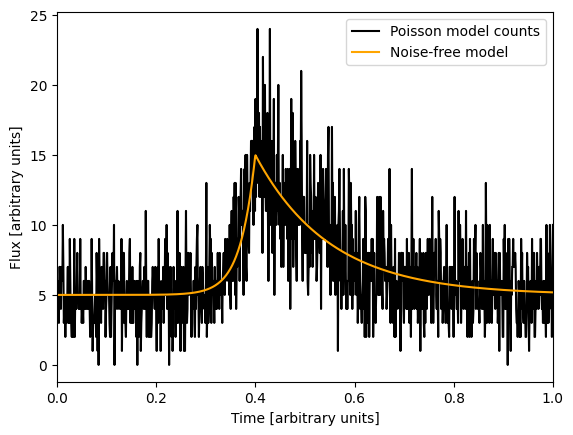

In [3]:
simulator.plot_burst()
plt.show()

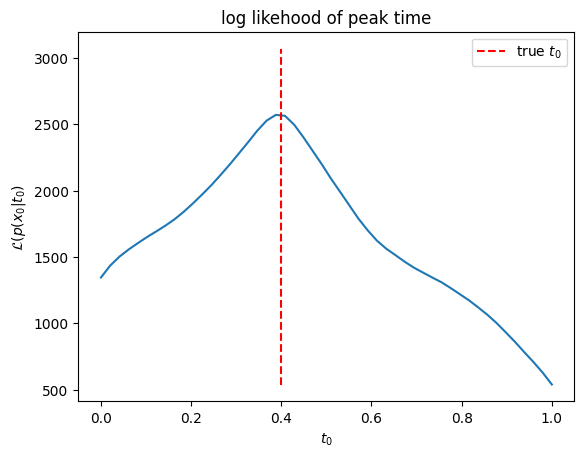

In [4]:
def log_likelihood(t0: float, modelparams, x_counts: Iterable[int]) -> float:
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
 
    # update model parameters
    modelparams['burstparams']['t0'] = [t0]

    # find noise-free flux
    model_counts = Model(
        time       = modelparams['time'], 
        ncomp      = modelparams['ncomp'], 
        burstparams= modelparams['burstparams'], 
        ybkg       = modelparams['ybkg']
    ).get_flux()
    
    # likelihood of the observed counts under this model
    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # Note x is simulated count and should always be integer
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L

true_t0 = simulator.get_true('t0')

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

t0s = np.linspace(0, 1, 50)
likelihoods = [log_likelihood(t0, modelparams, simulator.simulated_counts) for t0 in t0s]

plt.plot(t0s, likelihoods)
plt.title("log likehood of peak time")
plt.ylabel("$\mathcal{L}(p(x_0 | t_0)$")
plt.xlabel("$t_0$")
plt.vlines([true_t0],  ymin=min(likelihoods), ymax=max(likelihoods) + 500, linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()

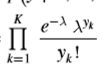

In [5]:
nwalkers = 20
ndim = 1
p0 = np.random.rand(nwalkers, ndim) # initial position of the walkers

def log_prob(t0: Iterable[float], *args) -> float:
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0 < 0 or t0 > 1:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[modelparams, x_counts])

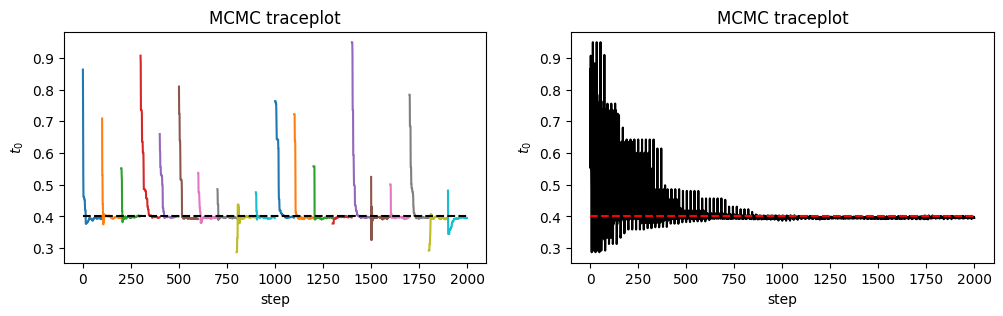

In [6]:
# burn-in 
burn_steps = 100
state = sampler.run_mcmc(p0, burn_steps)
plot_trace(sampler, burn_steps, true_t0)
sampler.reset()

In [7]:
steps = 1000
sampler.run_mcmc(state, 1000)

State([[0.3989013 ]
 [0.39946197]
 [0.39215033]
 [0.39932636]
 [0.39203402]
 [0.39501627]
 [0.3965257 ]
 [0.39608512]
 [0.39883545]
 [0.39789351]
 [0.39299443]
 [0.39675599]
 [0.39858567]
 [0.398307  ]
 [0.39574258]
 [0.39554621]
 [0.39545239]
 [0.39764136]
 [0.39483883]
 [0.39685229]], log_prob=[2575.81531177 2575.5703056  2575.47440289 2575.63642785 2575.39055208
 2576.40116703 2576.3775199  2576.39289999 2575.84627228 2576.16891846
 2575.9180031  2576.34558641 2575.97165273 2576.08735784 2576.4069131
 2576.4252891  2576.43673148 2576.2353035  2576.390433   2576.33532507], blobs=None, random_state=('MT19937', array([ 810073554, 3624746320, 3686750169, 3034144575, 1542002861,
       1993791172, 3738075066,  874635418, 1844456477, 3557710681,
       1558489193, 1790010381, 2333599311, 3817506997,  614854385,
       2349200068, 3521718968,   88706552, 1625434036, 3288536967,
       2754780029, 2988288959, 2879537414,  178296721,  245610738,
       1371186531, 2293454927, 3415248499, 313

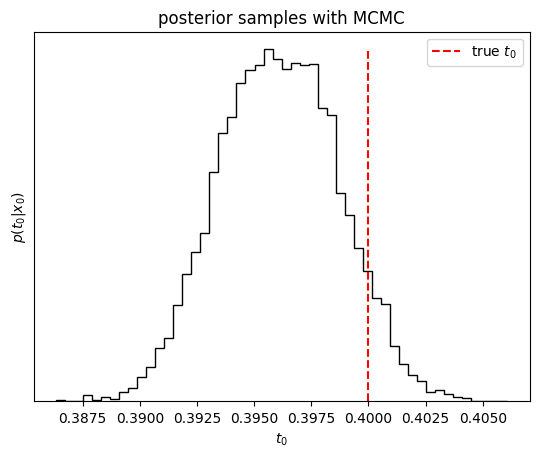

In [8]:
samples = sampler.get_chain(flat=True)

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines(true_t0,  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_0$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

In [9]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

# TODO: Diagnose mcmc Trace plots chains as a func of iteration (ideally should be white noise)
# Autocorrelation time check
# add plots where you overlay samples from the posterior on the data

Mean acceptance fraction: 0.808


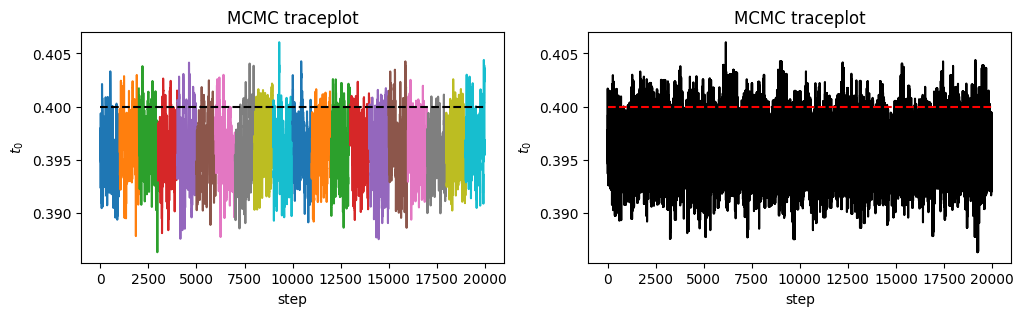

In [10]:
# trace plot
plot_trace(sampler, steps, true_t0)
plt.show()

# Two peaks

In [35]:
time = np.linspace(0, 1, 1000)
N = 2

amp = 16.0
t0 = 0.1
rise = 0.03
skew = 5
ybkg = 5.0

burstparams = {
    't0'   : [t0, t0+0.5],
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
x_model, x_counts = simulator.simulate_burst(return_model=True)

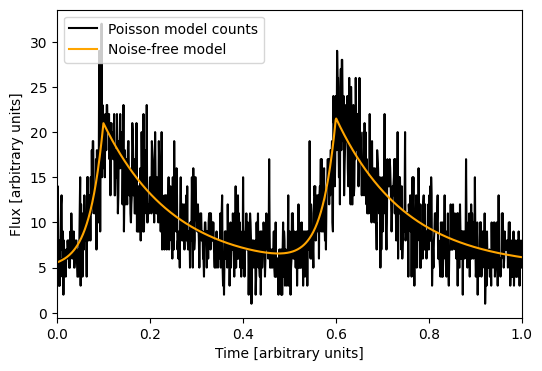

In [36]:
plt.figure(figsize=(6,4))
simulator.plot_burst()
plt.show()

In [43]:
def log_likelihood(t0: Iterable[float], modelparams: dict, x_counts: Iterable[int]) -> float:
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
 
    # update model parameters
    modelparams['burstparams']['t0'] = t0

    # find noise-free flux
    model_counts = Model(
        time       = modelparams['time'], 
        ncomp      = modelparams['ncomp'], 
        burstparams= modelparams['burstparams'], 
        ybkg       = modelparams['ybkg']
    ).get_flux()
    
    # likelihood of the observed counts under this model
    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # Note x is simulated count and should always be integer
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L


def log_prob(t0, *args):
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0.any() < 0 or t0.any() > 1:
        return -np.inf
        
    # peak time of first peak should be smaller than second peak etc. etc.
    if t0[0] > t0[1]:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

nwalkers = 20
ndim = 2
p0 = np.sort(np.random.rand(nwalkers, ndim), axis=1)  # initial position of the walkers, SAMPLE FROM THE PRIOR, SO ENSURE t0_1 < t0_2

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[modelparams, x_counts])

In [44]:
# burn-in of 100 steps
burn_steps = 300
steps = 2000

sampler.reset()
state = sampler.run_mcmc(p0, burn_steps)

sampler.reset()
sampler.run_mcmc(state, steps)

State([[0.09741754 0.59551283]
 [0.09996724 0.59695792]
 [0.10221908 0.59445326]
 [0.09857948 0.59489876]
 [0.09547537 0.59744781]
 [0.09869412 0.59522242]
 [0.10275992 0.59713683]
 [0.10148167 0.5969231 ]
 [0.09692623 0.59680896]
 [0.09846189 0.59478636]
 [0.10097408 0.59670487]
 [0.1011003  0.60033019]
 [0.09704454 0.60086275]
 [0.09947803 0.59562755]
 [0.09916248 0.59497686]
 [0.10075571 0.59751065]
 [0.09775431 0.59852959]
 [0.10013469 0.59679321]
 [0.09876886 0.59904133]
 [0.09673857 0.59928766]], log_prob=[5747.00544869 5747.59567651 5745.17527401 5746.99219998 5745.49759657
 5747.20358119 5745.66135613 5746.78029309 5747.03168003 5746.92100744
 5747.16306162 5745.82965362 5745.25204958 5747.4390518  5747.09408339
 5747.20549637 5747.23936191 5747.58580251 5747.2647235  5746.30698529], blobs=None, random_state=('MT19937', array([ 348909229, 1946267593, 1874543969, 3615819746, 2000299290,
       4053940174, 4027234394, 2143198515, 1706524353, 4165695696,
       1073468586, 2379006

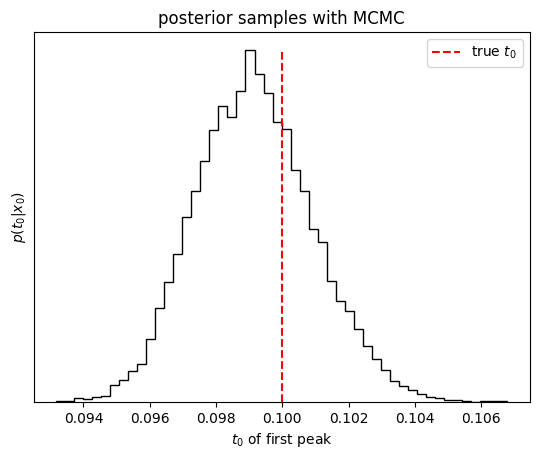

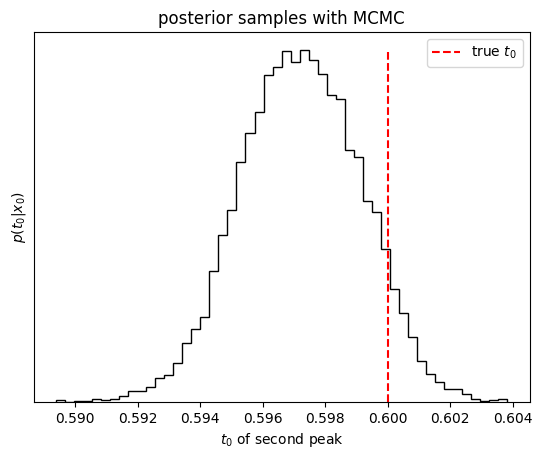

array([[0.09837857, 0.59347435],
       [0.10181633, 0.59671675],
       [0.09660923, 0.59637239],
       ...,
       [0.10013469, 0.59679321],
       [0.09876886, 0.59904133],
       [0.09673857, 0.59928766]])

In [45]:
samples = sampler.get_chain(flat=True)
true_t0 = simulator.get_true('t0')

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines(true_t0[0],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_{0}$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of first peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

frequencies, _, _ = plt.hist(samples[:, 1], 50, color="k", histtype="step")
plt.vlines(true_t0[1],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_{0}$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of second peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

samples

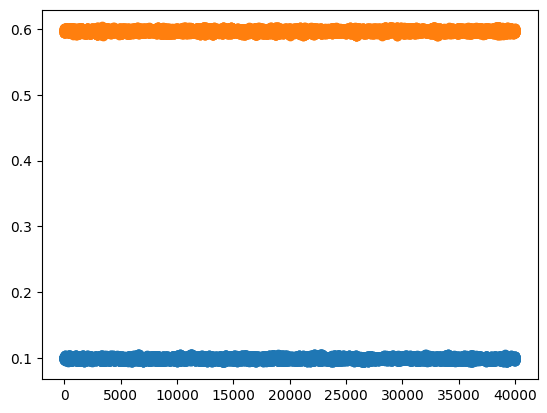

In [46]:
plt.plot(sampler.get_chain(flat=True), 'o')

In [41]:
# Normalizing flow

# generate bunch of training data (all params fixed except t0?)

# generate posterior using normalizing flow ?

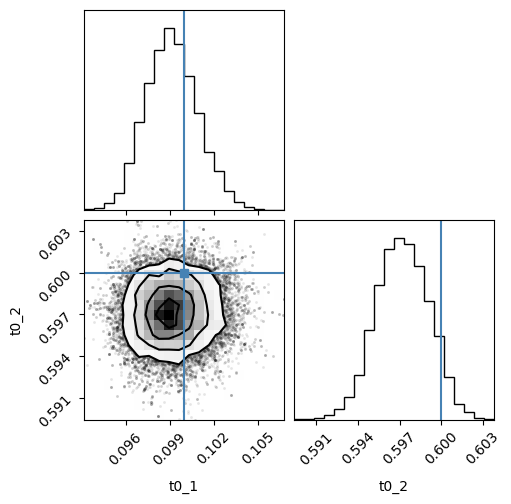

In [47]:
from corner import corner

fig = corner(samples, labels=["t0_1", "t0_2"], truths=true_t0)

In [48]:
tau = sampler.get_autocorr_time()
print(tau)

print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

[29.18437016 31.15900009]
Mean acceptance fraction: 0.718


Text(0.5, 0, 'step number')

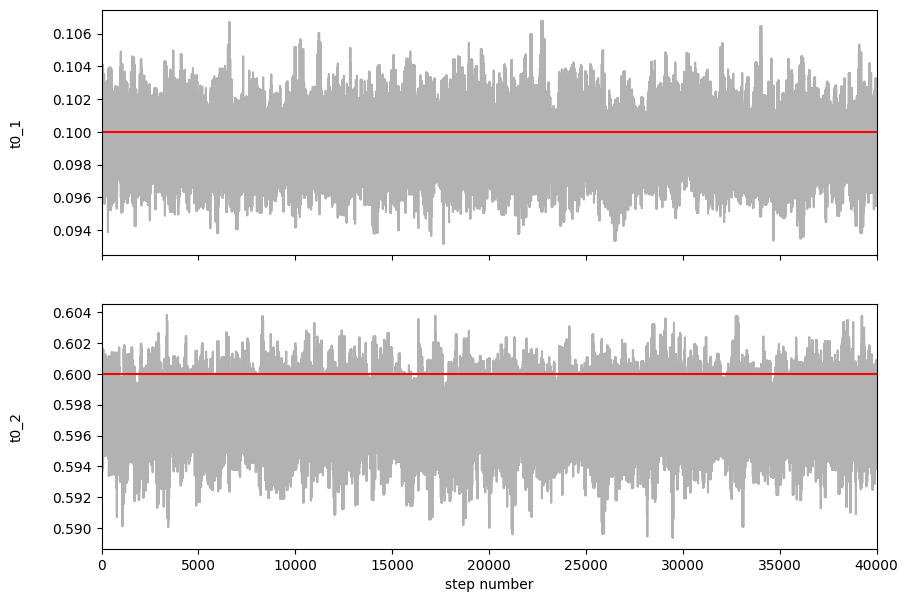

In [49]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
labels = ["t0_1", "t0_2"]

for i in range(2):
    ax = axes[i]
    ax.plot(samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.hlines([true_t0[i]], xmin=0, xmax=2*nwalkers*steps, color='red')
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

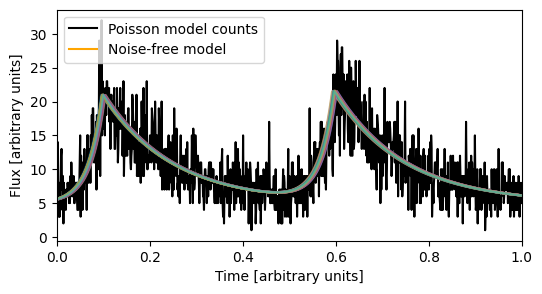

In [50]:
# Draw samples from posterior and overlay onto simulated data
# get t01 and t02 from the samples from the sampler and 
samples.shape

plt.figure(figsize=(6,3))
simulator.plot_burst()

for _ in range(100):
    random_index = np.random.randint(low=0, high=len(samples))
    random_sample = samples[random_index]
    burstparams['t0'] = random_sample
    model = Model(time, N, burstparams, ybkg).get_flux()
    plt.plot(time, model, alpha=0.5)